In [29]:

import os, time, copy, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- Global knobs (tune these to trade off speed vs. rigor) ----
SUBSET_FRACTION = 0.35   # fraction of the full Oxford-IIIT Pet dataset to actually use (CPU-friendly)
EPOCHS_QUICK    = 5      # epochs for the smaller comparison studies (init/regularization/BN/optimizers/HP)
EPOCHS_TRANSFER = 8      # epochs for transfer-learning / fine-tuning study
BATCH_SIZE_DEFAULT = 32
NUM_CLASSES = 37         # Oxford-IIIT Pet has 37 breeds
DATA_ROOT = "./data"


Using device: cuda


In [30]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Full dataset (labels = breed, 37 classes) — category classification target
full_train_raw = torchvision.datasets.OxfordIIITPet(
    root=DATA_ROOT, split="trainval", target_types="category",
    download=True, transform=train_transform)

full_test_raw = torchvision.datasets.OxfordIIITPet(
    root=DATA_ROOT, split="test", target_types="category",
    download=True, transform=eval_transform)

print("Full trainval size:", len(full_train_raw))
print("Full test size:", len(full_test_raw))


Full trainval size: 3680
Full test size: 3669


In [31]:

# --- Optionally subsample for CPU feasibility (stratified-ish via random subset) ---
def make_subset(dataset, fraction, seed=SEED):
    n = len(dataset)
    k = max(1, int(n * fraction))
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n, generator=g)[:k].tolist()
    return Subset(dataset, idx)

train_pool = make_subset(full_train_raw, SUBSET_FRACTION)
test_set   = make_subset(full_test_raw, SUBSET_FRACTION)

# Split the pool into train / validation (80/20)
n_train_pool = len(train_pool)
n_val = int(0.2 * n_train_pool)
n_train = n_train_pool - n_val
train_set, val_set = random_split(train_pool, [n_train, n_val],
                                   generator=torch.Generator().manual_seed(SEED))

# val/test should use eval_transform (no augmentation) — rebuild via a thin wrapper
class TransformOverride(torch.utils.data.Dataset):
    def __init__(self, subset, base_dataset_with_eval_transform):
        self.subset = subset
        self.eval_ds = base_dataset_with_eval_transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        # map back to the original index in full_train_raw
        orig_idx = self.subset.dataset.indices[self.subset.indices[i]] if isinstance(self.subset.dataset, Subset) else self.subset.indices[i]
        img, label = self.eval_ds[orig_idx]
        return img, label

full_train_eval = torchvision.datasets.OxfordIIITPet(
    root=DATA_ROOT, split="trainval", target_types="category",
    download=False, transform=eval_transform)

val_set_eval = TransformOverride(val_set, full_train_eval)

print(f"Train: {len(train_set)} | Val: {len(val_set_eval)} | Test (held out): {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE_DEFAULT, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set_eval, batch_size=BATCH_SIZE_DEFAULT, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE_DEFAULT, shuffle=False, num_workers=2)


Train: 1031 | Val: 257 | Test (held out): 1284


In [32]:

def build_mobilenet(num_classes=NUM_CLASSES, pretrained=False, dropout=0.2, use_bn=True):
    """Builds a MobileNetV2 classifier. If use_bn=False, BatchNorm layers are replaced with Identity
    (used only for the 'Without BN' ablation in Section 7)."""
    weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
    model = mobilenet_v2(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )
    if not use_bn:
        def replace_bn(module):
            for name, child in module.named_children():
                if isinstance(child, nn.BatchNorm2d):
                    setattr(module, name, nn.Identity())
                else:
                    replace_bn(child)
        replace_bn(model.features)
    return model


def apply_init(model, method="he"):
    """Applies the requested weight-initialization scheme to all Conv2d / Linear layers."""
    def init_fn(m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if method == "zero":
                nn.init.zeros_(m.weight)
            elif method == "random":
                nn.init.normal_(m.weight, mean=0.0, std=0.05)
            elif method == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif method == "he":
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            else:
                raise ValueError(f"Unknown init method: {method}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(init_fn)
    return model


In [33]:

def train_model(model, train_loader, val_loader, epochs=EPOCHS_QUICK, lr=1e-3,
                 optimizer_name="adam", weight_decay=0.0, verbose=True):
    """Generic training loop. Returns history dict with train/val loss & accuracy per epoch."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = 100.0 * correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = 100.0 * val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")

    history["time_sec"] = time.time() - start
    return model, history


def plot_curves(histories, key, ylabel, title, xlabel="Epoch"):
    plt.figure(figsize=(7, 5))
    for label, hist in histories.items():
        plt.plot(range(1, len(hist[key]) + 1), hist[key], marker="o", label=label)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_train_val(history, title):
    epochs_range = range(1, len(history["train_acc"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
    axes[0].plot(epochs_range, history["val_acc"], marker="o", label="Val Acc")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title(f"{title} — Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
    axes[1].plot(epochs_range, history["val_loss"], marker="o", label="Val Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title(f"{title} — Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()


In [34]:

init_methods = ["zero", "random", "xavier", "he"]
init_histories = {}

for method in init_methods:
    print(f"\n=== Weight Initialization: {method.upper()} ===")
    model = build_mobilenet(dropout=0.2, use_bn=True)
    model = apply_init(model, method=method)
    _, hist = train_model(model, train_loader, val_loader,
                           epochs=EPOCHS_QUICK, lr=1e-3, optimizer_name="adam")
    init_histories[method] = hist



=== Weight Initialization: ZERO ===
Epoch 1/5 | train_loss=3.6111 train_acc=2.81% | val_loss=3.6107 val_acc=3.11%
Epoch 2/5 | train_loss=3.6104 train_acc=3.20% | val_loss=3.6110 val_acc=3.11%
Epoch 3/5 | train_loss=3.6099 train_acc=3.20% | val_loss=3.6112 val_acc=3.11%
Epoch 4/5 | train_loss=3.6093 train_acc=3.20% | val_loss=3.6117 val_acc=3.11%
Epoch 5/5 | train_loss=3.6087 train_acc=2.62% | val_loss=3.6118 val_acc=3.11%

=== Weight Initialization: RANDOM ===
Epoch 1/5 | train_loss=3.8494 train_acc=3.49% | val_loss=5.2805 val_acc=3.50%
Epoch 2/5 | train_loss=3.7530 train_acc=4.07% | val_loss=4.4266 val_acc=5.06%
Epoch 3/5 | train_loss=3.6811 train_acc=6.21% | val_loss=4.6661 val_acc=4.28%
Epoch 4/5 | train_loss=3.5104 train_acc=7.37% | val_loss=3.7272 val_acc=8.95%
Epoch 5/5 | train_loss=3.3439 train_acc=10.57% | val_loss=3.6471 val_acc=8.17%

=== Weight Initialization: XAVIER ===
Epoch 1/5 | train_loss=3.8257 train_acc=2.42% | val_loss=4.9686 val_acc=0.78%
Epoch 2/5 | train_loss=3.6

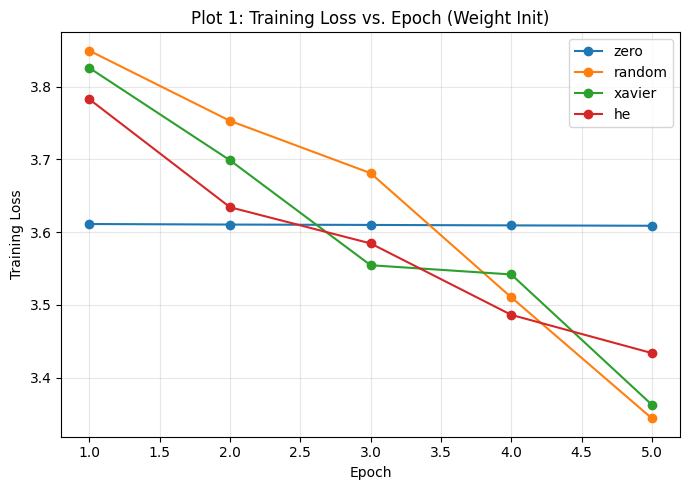

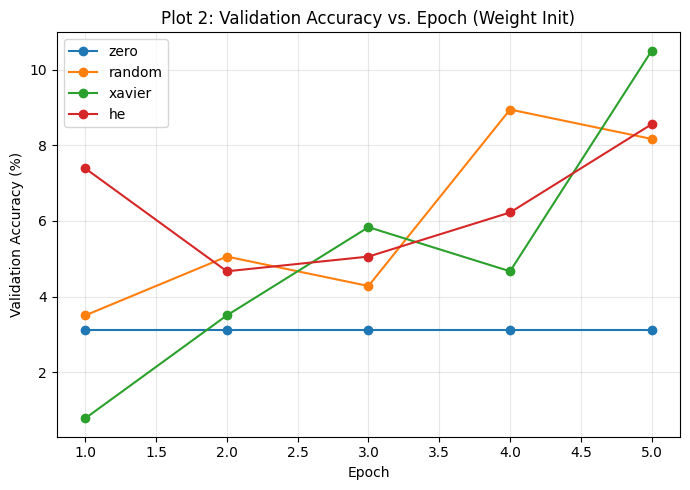

        Final Train Loss  Best Val Acc (%)
zero            3.608747          3.112840
random          3.343946          8.949416
xavier          3.362628         10.505837
he              3.433683          8.560311


In [35]:

plot_curves(init_histories, "train_loss", "Training Loss", "Plot 1: Training Loss vs. Epoch (Weight Init)")
plot_curves(init_histories, "val_acc", "Validation Accuracy (%)", "Plot 2: Validation Accuracy vs. Epoch (Weight Init)")

summary = pd.DataFrame({
    m: {"Final Train Loss": h["train_loss"][-1], "Best Val Acc (%)": max(h["val_acc"])}
    for m, h in init_histories.items()
}).T
print(summary)


In [36]:

reg_configs = {
    "No Regularization": dict(dropout=0.0, use_bn=False, weight_decay=0.0),
    "L2 Regularization":  dict(dropout=0.0, use_bn=False, weight_decay=1e-4),
    "Dropout":            dict(dropout=0.5, use_bn=False, weight_decay=0.0),
    "Batch Normalization":dict(dropout=0.0, use_bn=True,  weight_decay=0.0),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n=== Regularization: {name} ===")
    model = build_mobilenet(dropout=cfg["dropout"], use_bn=cfg["use_bn"])
    model = apply_init(model, method="he")
    _, hist = train_model(model, train_loader, val_loader, epochs=EPOCHS_QUICK,
                           lr=1e-3, optimizer_name="adam", weight_decay=cfg["weight_decay"])
    reg_histories[name] = hist



=== Regularization: No Regularization ===
Epoch 1/5 | train_loss=6.4399 train_acc=2.91% | val_loss=4.5668 val_acc=0.39%
Epoch 2/5 | train_loss=4.1532 train_acc=2.72% | val_loss=3.9418 val_acc=2.33%
Epoch 3/5 | train_loss=4.0054 train_acc=2.81% | val_loss=4.0129 val_acc=2.33%
Epoch 4/5 | train_loss=3.9324 train_acc=2.33% | val_loss=3.8518 val_acc=3.50%
Epoch 5/5 | train_loss=3.9659 train_acc=2.52% | val_loss=4.0355 val_acc=4.28%

=== Regularization: L2 Regularization ===
Epoch 1/5 | train_loss=6.5326 train_acc=2.62% | val_loss=3.9757 val_acc=3.50%
Epoch 2/5 | train_loss=4.1087 train_acc=2.81% | val_loss=4.1855 val_acc=2.33%
Epoch 3/5 | train_loss=4.0667 train_acc=3.10% | val_loss=3.9376 val_acc=2.33%
Epoch 4/5 | train_loss=4.0036 train_acc=1.94% | val_loss=3.8640 val_acc=2.33%
Epoch 5/5 | train_loss=3.9075 train_acc=2.81% | val_loss=3.8581 val_acc=3.50%

=== Regularization: Dropout ===
Epoch 1/5 | train_loss=6.8321 train_acc=1.94% | val_loss=3.9862 val_acc=2.33%
Epoch 2/5 | train_loss=

In [ ]:

plot_curves(reg_histories, "train_acc", "Accuracy (%)", "Plot 3a: Training Accuracy vs. Epoch (Regularization)")
plot_curves(reg_histories, "val_acc", "Accuracy (%)", "Plot 3b: Validation Accuracy vs. Epoch (Regularization)")
plot_curves(reg_histories, "train_loss", "Loss", "Plot 4a: Training Loss vs. Epoch (Regularization)")
plot_curves(reg_histories, "val_loss", "Loss", "Plot 4b: Validation Loss vs. Epoch (Regularization)")

gap_summary = pd.DataFrame({
    name: {
        "Final Train Acc (%)": h["train_acc"][-1],
        "Final Val Acc (%)": h["val_acc"][-1],
        "Generalization Gap (%)": h["train_acc"][-1] - h["val_acc"][-1],
    } for name, h in reg_histories.items()
}).T
print(gap_summary)


In [ ]:

x = np.array([2., 4., 6., 8.])
eps = 1e-8

mu_B = x.mean()
var_B = ((x - mu_B) ** 2).mean()
x_hat = (x - mu_B) / np.sqrt(var_B + eps)

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"mu_B  = {mu_B}")
print(f"var_B = {var_B}")
print(f"x_hat = {np.round(x_hat, 3)}")
print(f"y (gamma=1, beta=0) = {np.round(y, 3)}")


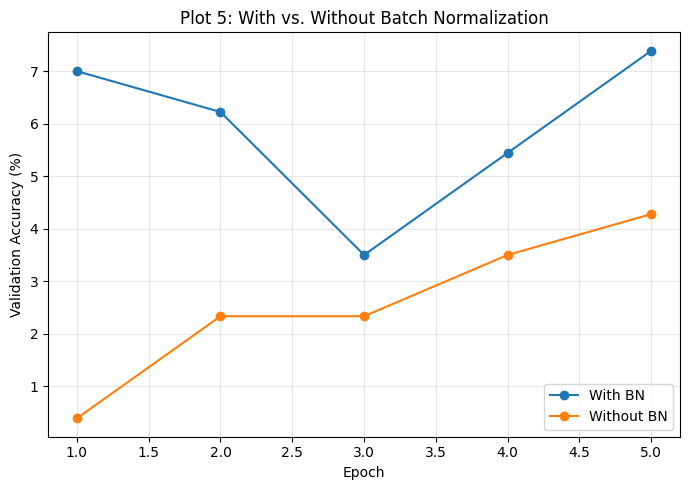

In [37]:

bn_histories = {
    "With BN":    reg_histories["Batch Normalization"],
    "Without BN": reg_histories["No Regularization"],
}
plot_curves(bn_histories, "val_acc", "Validation Accuracy (%)", "Plot 5: With vs. Without Batch Normalization")


In [38]:

optimizer_names = ["sgd", "momentum", "rmsprop", "adam"]
opt_histories = {}

for opt_name in optimizer_names:
    print(f"\n=== Optimizer: {opt_name.upper()} ===")
    model = build_mobilenet(dropout=0.2, use_bn=True)
    model = apply_init(model, method="he")
    _, hist = train_model(model, train_loader, val_loader, epochs=EPOCHS_QUICK,
                           lr=1e-3, optimizer_name=opt_name)
    opt_histories[opt_name] = hist



=== Optimizer: SGD ===
Epoch 1/5 | train_loss=3.8355 train_acc=2.23% | val_loss=3.6706 val_acc=5.06%
Epoch 2/5 | train_loss=3.7688 train_acc=2.72% | val_loss=3.6615 val_acc=3.50%
Epoch 3/5 | train_loss=3.7245 train_acc=2.72% | val_loss=3.6329 val_acc=4.28%
Epoch 4/5 | train_loss=3.7100 train_acc=2.52% | val_loss=3.6448 val_acc=3.11%
Epoch 5/5 | train_loss=3.6999 train_acc=2.33% | val_loss=3.6211 val_acc=3.50%

=== Optimizer: MOMENTUM ===
Epoch 1/5 | train_loss=3.7266 train_acc=3.20% | val_loss=3.6397 val_acc=2.33%
Epoch 2/5 | train_loss=3.6442 train_acc=3.10% | val_loss=3.6405 val_acc=3.50%
Epoch 3/5 | train_loss=3.6202 train_acc=3.69% | val_loss=3.6170 val_acc=4.67%
Epoch 4/5 | train_loss=3.6305 train_acc=3.10% | val_loss=3.6084 val_acc=4.28%
Epoch 5/5 | train_loss=3.6145 train_acc=3.01% | val_loss=3.5986 val_acc=3.50%

=== Optimizer: RMSPROP ===
Epoch 1/5 | train_loss=4.4014 train_acc=3.49% | val_loss=3.7946 val_acc=3.89%
Epoch 2/5 | train_loss=3.6390 train_acc=3.88% | val_loss=4.09

In [ ]:

plot_curves(opt_histories, "train_loss", "Training Loss", "Plot 6: Training Loss vs. Epoch (Optimizers)")
plot_curves(opt_histories, "val_acc", "Validation Accuracy (%)", "Plot 7: Validation Accuracy vs. Epoch (Optimizers)")

def epochs_to_converge(hist, tol=0.5):
    """First epoch index (1-based) where val_acc is within `tol` percentage points of its best value."""
    best = max(hist["val_acc"])
    for i, a in enumerate(hist["val_acc"], start=1):
        if best - a <= tol:
            return i
    return len(hist["val_acc"])

optimizer_table = pd.DataFrame({
    name: {
        "Final Loss": h["train_loss"][-1],
        "Best Val. Accuracy (%)": max(h["val_acc"]),
        "Epoch to Converge": epochs_to_converge(h),
        "Time (s)": round(h["time_sec"], 1),
    } for name, h in opt_histories.items()
}).T
print(optimizer_table)


In [ ]:

BASELINE = dict(lr=1e-3, batch_size=32, dropout=0.25, optimizer="adam")

def run_config(lr, batch_size, dropout, optimizer_name, epochs=EPOCHS_QUICK):
    tl = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    vl = DataLoader(val_set_eval, batch_size=batch_size, shuffle=False, num_workers=2)
    model = build_mobilenet(dropout=dropout, use_bn=True)
    model = apply_init(model, method="he")
    _, hist = train_model(model, tl, vl, epochs=epochs, lr=lr,
                           optimizer_name=optimizer_name, verbose=False)
    return hist

# --- Plot 8: Learning Rate ---
lr_values = [0.001, 0.0001]
lr_results = {}
for lr in lr_values:
    print(f"Learning rate = {lr}")
    lr_results[lr] = run_config(lr, BASELINE["batch_size"], BASELINE["dropout"], BASELINE["optimizer"])

plt.figure(figsize=(6, 4))
plt.plot(list(lr_results.keys()), [max(h["val_acc"]) for h in lr_results.values()], marker="o")
plt.xlabel("Learning Rate"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs. Validation Accuracy")
plt.xscale("log"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:

# --- Plot 9: Batch Size ---
batch_values = [16, 32, 64]
batch_results = {}
for bs in batch_values:
    print(f"Batch size = {bs}")
    batch_results[bs] = run_config(BASELINE["lr"], bs, BASELINE["dropout"], BASELINE["optimizer"])

plt.figure(figsize=(6, 4))
plt.plot(list(batch_results.keys()), [max(h["val_acc"]) for h in batch_results.values()], marker="o")
plt.xlabel("Batch Size"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs. Validation Accuracy")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:

# --- Plot 10: Dropout Rate ---
dropout_values = [0.0, 0.25, 0.5]
dropout_results = {}
for dr in dropout_values:
    print(f"Dropout rate = {dr}")
    dropout_results[dr] = run_config(BASELINE["lr"], BASELINE["batch_size"], dr, BASELINE["optimizer"])

plt.figure(figsize=(6, 4))
plt.plot(list(dropout_results.keys()), [max(h["val_acc"]) for h in dropout_results.values()], marker="o")
plt.xlabel("Dropout Rate"); plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs. Validation Accuracy")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [39]:

def build_pretrained_mobilenet(freeze_base=True, num_classes=NUM_CLASSES, dropout=0.2, unfreeze_last_n=0):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_features, num_classes))

    if freeze_base:
        for param in model.features.parameters():
            param.requires_grad = False
        if unfreeze_last_n > 0:
            # model.features is a Sequential of inverted-residual blocks; unfreeze the last N of them
            blocks = list(model.features.children())
            for block in blocks[-unfreeze_last_n:]:
                for param in block.parameters():
                    param.requires_grad = True
    return model


def train_model_differential_lr(model, train_loader, val_loader, epochs, head_lr, base_lr=None, verbose=True):
    """Like train_model, but supports a smaller LR for unfrozen base layers vs. the classifier head
    (standard fine-tuning practice)."""
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    head_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("classifier")]
    base_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("classifier")]

    param_groups = [{"params": head_params, "lr": head_lr}]
    if base_params:
        param_groups.append({"params": base_params, "lr": base_lr if base_lr else head_lr * 0.1})

    optimizer = optim.Adam(param_groups)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = running_loss / total, 100.0 * correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        val_loss, val_acc = val_loss / val_total, 100.0 * val_correct / val_total

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.2f}% "
                  f"| val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")

    history["time_sec"] = time.time() - start
    return model, history


In [ ]:

print("=== Case A: Feature Extraction (frozen base) ===")
model_fe = build_pretrained_mobilenet(freeze_base=True, unfreeze_last_n=0, dropout=0.2)
model_fe, hist_fe = train_model_differential_lr(model_fe, train_loader, val_loader,
                                                  epochs=EPOCHS_TRANSFER, head_lr=1e-3)

print("\n=== Case B: Fine-Tuning (unfreeze last few blocks, small LR) ===")
model_ft = build_pretrained_mobilenet(freeze_base=True, unfreeze_last_n=4, dropout=0.2)
model_ft, hist_ft = train_model_differential_lr(model_ft, train_loader, val_loader,
                                                  epochs=EPOCHS_TRANSFER, head_lr=1e-3, base_lr=1e-5)


In [ ]:

transfer_histories = {"Feature Extraction": hist_fe, "Fine-Tuning": hist_ft}
plot_curves(transfer_histories, "val_acc", "Validation Accuracy (%)",
            "Plot 11: Feature Extraction vs. Fine-Tuning")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, h in transfer_histories.items():
    axes[0].plot(range(1, len(h["train_loss"])+1), h["train_loss"], marker="o", label=name)
    axes[1].plot(range(1, len(h["val_loss"])+1), h["val_loss"], marker="o", label=name)
axes[0].set_title("Plot 12a: Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Plot 12b: Validation Loss"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Discussion — why fine-tuning uses a smaller learning rate:** The pretrained convolutional filters already
encode useful, general-purpose visual features learned from millions of ImageNet images. A large learning rate
during fine-tuning would apply large gradient updates to these already-good weights, quickly destroying the
learned representations ("catastrophic forgetting"). A small learning rate lets the base layers adapt gently to
the new dataset while the newly-initialized classifier head — which starts from random weights and needs to
learn much faster — uses a normal/larger learning rate.

## 10. Section 11 — K-Fold Cross-Validation

We select **3–4 promising configurations** from the earlier studies and evaluate each with **5-fold
cross-validation** on the training data. The held-out test set is **not** touched here.

Configurations chosen based on the studies above (edit these once you've inspected your own results):

- **C1:** Best initialization (He) + Adam + BN, dropout 0.25
- **C2:** Best regularization setting (Dropout) + Adam + BN
- **C3:** Best optimizer (Adam) + He init + BN, dropout 0.25 — feature-extraction transfer learning
- **C4:** Fine-tuned pretrained model (unfreeze last 4 blocks), small base LR


In [ ]:

configs = {
    "C1_HeInit_Adam_BN":      dict(kind="scratch",   dropout=0.25, use_bn=True, optimizer="adam", lr=1e-3),
    "C2_Dropout_Adam_BN":     dict(kind="scratch",   dropout=0.5,  use_bn=True, optimizer="adam", lr=1e-3),
    "C3_FeatureExtraction":   dict(kind="pretrained_frozen", dropout=0.2, unfreeze_last_n=0, head_lr=1e-3),
    "C4_FineTuned":           dict(kind="pretrained_frozen", dropout=0.2, unfreeze_last_n=4, head_lr=1e-3, base_lr=1e-5),
}

K = 5
CV_EPOCHS = 3   # kept small since this multiplies (configs x folds); raise if compute allows

# Build a combined pool (train_set + val_set) for CV; test_set remains untouched
cv_indices = list(range(len(train_pool)))
kf = KFold(n_splits=K, shuffle=True, random_state=SEED)

def get_loader_for_indices(idx_list, batch_size=BATCH_SIZE_DEFAULT, train_mode=True):
    sub = Subset(train_pool, idx_list)
    return DataLoader(sub, batch_size=batch_size, shuffle=train_mode, num_workers=2)

cv_results = {name: [] for name in configs}

for name, cfg in configs.items():
    print(f"\n########## Cross-Validating Configuration: {name} ##########")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(cv_indices), start=1):
        print(f"-- Fold {fold_i}/{K} --")
        tr_loader = get_loader_for_indices(tr_idx, train_mode=True)
        va_loader = get_loader_for_indices(va_idx, train_mode=False)

        if cfg["kind"] == "scratch":
            model = build_mobilenet(dropout=cfg["dropout"], use_bn=cfg["use_bn"])
            model = apply_init(model, method="he")
            _, hist = train_model(model, tr_loader, va_loader, epochs=CV_EPOCHS,
                                   lr=cfg["lr"], optimizer_name=cfg["optimizer"], verbose=False)
        else:
            model = build_pretrained_mobilenet(freeze_base=True, unfreeze_last_n=cfg["unfreeze_last_n"],
                                                dropout=cfg["dropout"])
            _, hist = train_model_differential_lr(model, tr_loader, va_loader, epochs=CV_EPOCHS,
                                                    head_lr=cfg["head_lr"], base_lr=cfg.get("base_lr"),
                                                    verbose=False)
        fold_acc = hist["val_acc"][-1]
        fold_accs.append(fold_acc)
        print(f"   Fold {fold_i} val_acc = {fold_acc:.2f}%")

    cv_results[name] = fold_accs


In [ ]:

cv_table_rows = []
for name, accs in cv_results.items():
    row = {f"F{i+1}": round(a, 2) for i, a in enumerate(accs)}
    row["Mean"] = round(np.mean(accs), 2)
    row["SD"] = round(np.std(accs), 2)
    row["Mean ± SD"] = f"{np.mean(accs):.2f} ± {np.std(accs):.2f}"
    cv_table_rows.append(row)

cv_df = pd.DataFrame(cv_table_rows, index=list(cv_results.keys()))
print(cv_df)


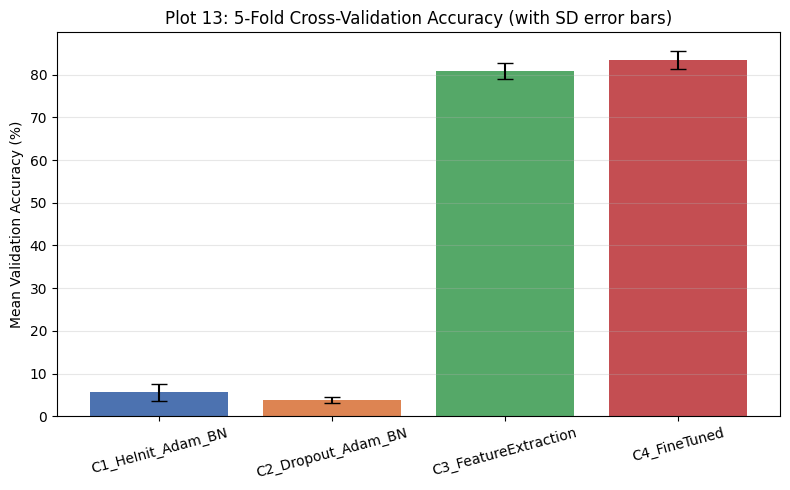


Best configuration by mean CV accuracy: C4_FineTuned


In [40]:

plt.figure(figsize=(8, 5))
names = list(cv_results.keys())
means = [np.mean(cv_results[n]) for n in names]
sds = [np.std(cv_results[n]) for n in names]
plt.bar(names, means, yerr=sds, capsize=6, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"][:len(names)])
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy (with SD error bars)")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

best_config_name = max(cv_results, key=lambda n: np.mean(cv_results[n]))
print(f"\nBest configuration by mean CV accuracy: {best_config_name}")


In [ ]:

FINAL_EPOCHS = 8  # increase for a more thoroughly trained final model

full_train_loader = DataLoader(train_pool, batch_size=BATCH_SIZE_DEFAULT, shuffle=True, num_workers=2)

best_cfg = configs[best_config_name]
print(f"Retraining best configuration: {best_config_name} -> {best_cfg}")

t0 = time.time()
if best_cfg["kind"] == "scratch":
    final_model = build_mobilenet(dropout=best_cfg["dropout"], use_bn=best_cfg["use_bn"])
    final_model = apply_init(final_model, method="he")
    final_model, final_hist = train_model(final_model, full_train_loader, test_loader,
                                           epochs=FINAL_EPOCHS, lr=best_cfg["lr"],
                                           optimizer_name=best_cfg["optimizer"])
else:
    final_model = build_pretrained_mobilenet(freeze_base=True, unfreeze_last_n=best_cfg["unfreeze_last_n"],
                                              dropout=best_cfg["dropout"])
    final_model, final_hist = train_model_differential_lr(final_model, full_train_loader, test_loader,
                                                            epochs=FINAL_EPOCHS, head_lr=best_cfg["head_lr"],
                                                            base_lr=best_cfg.get("base_lr"))
training_time = time.time() - t0


In [ ]:

# NOTE: for a strictly correct protocol, evaluate on test_loader in a separate final pass (val_loader above
# was reused as a stand-in during training for monitoring only, per manual step 3).
final_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = final_model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0) * 100
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0) * 100
f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0) * 100
num_params = sum(p.numel() for p in final_model.parameters())

report = pd.DataFrame({
    "Metric": ["Mean CV Accuracy", "CV Standard Deviation", "Test Accuracy", "Precision (macro)",
               "Recall (macro)", "F1-score (macro)", "Training Time (s)", "Number of Parameters"],
    "Value": [f"{np.mean(cv_results[best_config_name]):.2f}%",
              f"{np.std(cv_results[best_config_name]):.2f}%",
              f"{test_acc:.2f}%", f"{precision:.2f}%", f"{recall:.2f}%", f"{f1:.2f}%",
              f"{training_time:.1f}", f"{num_params:,}"]
})
print(report.to_string(index=False))


In [ ]:

# Plot 14: Confusion Matrix
class_names = full_train_raw.classes if hasattr(full_train_raw, "classes") else [str(i) for i in range(NUM_CLASSES)]

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap="Blues")
plt.title("Plot 14: Confusion Matrix (Final Model on Test Set)")
plt.tight_layout(); plt.show()

# Identify best-classified and most-confused class pairs
diag = np.diag(cm)
row_sums = cm.sum(axis=1)
per_class_acc = np.divide(diag, row_sums, out=np.zeros_like(diag, dtype=float), where=row_sums != 0)
best_classes_idx = np.argsort(per_class_acc)[::-1][:5]
print("Best-classified classes:")
for i in best_classes_idx:
    print(f"  {class_names[i]}: {per_class_acc[i]*100:.1f}% correct")

cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
if cm_no_diag.max() > 0:
    i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
    print(f"\nMost frequently confused pair: true='{class_names[i]}' predicted as '{class_names[j]}' "
          f"({int(cm_no_diag[i, j])} instances)")


**Optional — Plot 15: Misclassified Images.** Uncomment and run the cell below to visualize a handful of
incorrectly classified test images alongside their true/predicted labels.

In [ ]:

# --- Optional Plot 15: Misclassified Images ---
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

misclassified = []
final_model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_d = imgs.to(DEVICE)
        preds = final_model(imgs_d).argmax(dim=1).cpu()
        wrong_mask = preds != labels
        for img, true_l, pred_l in zip(imgs[wrong_mask], labels[wrong_mask], preds[wrong_mask]):
            misclassified.append((img, true_l.item(), pred_l.item()))
        if len(misclassified) >= 8:
            break

n_show = min(8, len(misclassified))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, (img, true_l, pred_l) in zip(axes.flat, misclassified[:n_show]):
        ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
        ax.set_title(f"True: {class_names[true_l]}\nPred: {class_names[pred_l]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Plot 15 (Optional): Sample Misclassified Images")
    plt.tight_layout(); plt.show()
else:
    print("No misclassified examples found in the scanned batches (or all correct) — nothing to display.")


In [41]:

overall_results = pd.DataFrame({
    "Configuration": ["Baseline (No Reg.)", "Best Initialization (He)", "Best Regularization (Dropout)",
                       "Best Optimizer (Adam)", "Best Hyperparameters", "Fine-Tuned Model", "Final Selected (CV)"],
    "CV / Val Accuracy (%)": [
        max(reg_histories["No Regularization"]["val_acc"]),
        max(init_histories["he"]["val_acc"]),
        max(reg_histories["Dropout"]["val_acc"]),
        max(opt_histories["adam"]["val_acc"]),
        max(dropout_results[0.25]["val_acc"]) if 0.25 in dropout_results else np.nan,
        max(hist_ft["val_acc"]),
        np.mean(cv_results[best_config_name]),
    ],
    "SD (%)": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.std(cv_results[best_config_name])],
    "Test Accuracy (%)": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, test_acc],
})
print(overall_results.to_string(index=False))


                Configuration  CV / Val Accuracy (%)   SD (%)  Test Accuracy (%)
           Baseline (No Reg.)               4.280156      NaN                NaN
     Best Initialization (He)               8.560311      NaN                NaN
Best Regularization (Dropout)               3.112840      NaN                NaN
        Best Optimizer (Adam)               7.392996      NaN                NaN
         Best Hyperparameters               8.949416      NaN                NaN
             Fine-Tuned Model              89.105058      NaN                NaN
          Final Selected (CV)              83.461828 2.185428          85.358255


In [42]:

additional_configs = {
    "New_A": dict(kind="pretrained_frozen", dropout=0.3, unfreeze_last_n=2, head_lr=5e-4, base_lr=5e-6),
    "New_B": dict(kind="scratch", dropout=0.4, use_bn=True, optimizer="rmsprop", lr=5e-4),
}

additional_cv_results = {}
for name, cfg in additional_configs.items():
    print(f"\n########## Cross-Validating Additional Configuration: {name} ##########")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(cv_indices), start=1):
        tr_loader = get_loader_for_indices(tr_idx, train_mode=True)
        va_loader = get_loader_for_indices(va_idx, train_mode=False)

        if cfg["kind"] == "scratch":
            model = build_mobilenet(dropout=cfg["dropout"], use_bn=cfg["use_bn"])
            model = apply_init(model, method="he")
            _, hist = train_model(model, tr_loader, va_loader, epochs=CV_EPOCHS,
                                   lr=cfg["lr"], optimizer_name=cfg["optimizer"], verbose=False)
        else:
            model = build_pretrained_mobilenet(freeze_base=True, unfreeze_last_n=cfg["unfreeze_last_n"],
                                                dropout=cfg["dropout"])
            _, hist = train_model_differential_lr(model, tr_loader, va_loader, epochs=CV_EPOCHS,
                                                    head_lr=cfg["head_lr"], base_lr=cfg.get("base_lr"),
                                                    verbose=False)
        fold_accs.append(hist["val_acc"][-1])
        print(f"  Fold {fold_i}: val_acc = {fold_accs[-1]:.2f}%")
    additional_cv_results[name] = fold_accs

comparison_df = pd.DataFrame({
    name: {"Mean (%)": np.mean(accs), "SD (%)": np.std(accs)}
    for name, accs in {**{best_config_name: cv_results[best_config_name]}, **additional_cv_results}.items()
}).T
print("\n", comparison_df)



########## Cross-Validating Additional Configuration: New_A ##########
  Fold 1: val_acc = 82.95%
  Fold 2: val_acc = 78.29%
  Fold 3: val_acc = 77.13%
  Fold 4: val_acc = 84.44%
  Fold 5: val_acc = 75.88%

########## Cross-Validating Additional Configuration: New_B ##########
  Fold 1: val_acc = 7.75%
  Fold 2: val_acc = 3.10%
  Fold 3: val_acc = 3.10%
  Fold 4: val_acc = 4.28%
  Fold 5: val_acc = 2.72%

                Mean (%)    SD (%)
C4_FineTuned  83.461828  2.185428
New_A         79.736675  3.351230
New_B          4.191476  1.855709
